In [1]:
import config_paths_ipynb

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option("display.width", 1000)
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import glycowork.glycan_data.stats as glwstats

from scipy import stats

from ibd_biom_glycoda.config import DATASETS_DIR, FIGURE_DIR
from ibd_biom_glycoda.utils import seed_everything
from ibd_biom_glycoda.data import prepare_ibd_dataset, apply_clr_transformation, load_dataset_excel
from ibd_biom_glycoda.analysis.association import preprocess_linear_modeling, check_vif, check_ols_diagnostics, collect_model_terms, run_permutation_fdr, analyze_disease_main_effects, plot_disease_volcano, plot_disease_barplot, analyze_disease_interactions, plot_interaction_lollipop
from ibd_biom_glycoda.plotting.style import rcparams_aga, generate_semantic_colors, create_figure_with_panels, save_figure_aga_compliant

# Seed everything
SEED = 42
seed_everything(SEED)

ALPHA = 0.05 # Significance threshold

# Override glycowork RNG
glwstats.rng = np.random.default_rng(SEED)

PALETTE = 'okabe_ito'
rcparams_aga(palette=PALETTE)
DISEASE_COLORS, COHORT_COLORS,  *_ = generate_semantic_colors(palette=PALETTE, preview=False)

Notebook config loaded. Project root added: C:\Users\konst\GitProjects\ibd-biom-glycoda


# Import and prepare data

In [2]:
# Import data
fname = "ibd_biom_prospective_dataset_baseline.xlsx"
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)
df_multi, coda_cols = prepare_ibd_dataset(df_ibd, binary=False, winsorize=False)

# Print dataset summary shapes
print(f"Loaded dataset shape: {df_ibd.shape}")
print(f"Prepared dataset shape: {df_multi.shape}")

Dropped 0 low abundant GP columns: []
Retained 24 GP columns: ['GP1_FA1', 'GP2_A2', 'GP3_A2B', 'GP4_FA2', 'GP5_M5', 'GP6_FA2B', 'GP7_A2G1', 'GP8_FA2_6_G1', 'GP9_FA2_3_G1', 'GP10_FA2_6_BG1', 'GP11_FA2_3_BG1', 'GP12_A2G2', 'GP13_A2BG2', 'GP14_FA2G2', 'GP15_FA2BG2', 'GP16_FA2G1S1', 'GP17_A2G2S1', 'GP18_FA2G2S1', 'GP19_FA2BG2S1', 'GP20__', 'GP21_A2G2S2', 'GP22_A2BG2S2', 'GP23_FA2G2S2', 'GP24_FA2BG2S2']
Loaded dataset shape: (1449, 31)
Prepared dataset shape: (1367, 31)


In [3]:
# Collect metadata
metadata_cols = ['Age', 'Sex', 'Cohort', 'DISEASE']
metadata_df = df_multi[metadata_cols]

# CLR transform
df_clr = df_multi.copy()
df_clr[coda_cols] = apply_clr_transformation(
    df_clr[coda_cols],
    group1=df_multi.index.tolist(),
    group2=[],
    gamma=0.1,
    custom_scale=None,
    seed=SEED
)

# Prepare for analysis with statsmodels
df_model = preprocess_linear_modeling(df_clr, disease_cat=['HC', 'SC', 'CD', 'UC'], center_age=True)

# Run association analysis

In [4]:
# Fixed‐effects (OLS)
results_fixed = {}
formula_rhs =  "C(DISEASE, Treatment('HC'))*Age + C(Sex, Treatment('F'))*Age + I(Age**2) + C(Cohort, Treatment('UK'))"

for glycan in coda_cols:
    formula = (
        f"{glycan} ~ "
        f"{formula_rhs}"
    )
    ols = smf.ols(formula, data=df_model).fit(cov_type='HC3')

    # number of OLS coefficients
    n_ols = len(ols.params)        
    print(f"{glycan}: estimating {n_ols} OLS coefficients")

    # Store OLS fit
    results_fixed[glycan] = ols

GP1_FA1: estimating 14 OLS coefficients
GP2_A2: estimating 14 OLS coefficients
GP3_A2B: estimating 14 OLS coefficients
GP4_FA2: estimating 14 OLS coefficients
GP5_M5: estimating 14 OLS coefficients
GP6_FA2B: estimating 14 OLS coefficients
GP7_A2G1: estimating 14 OLS coefficients
GP8_FA2_6_G1: estimating 14 OLS coefficients
GP9_FA2_3_G1: estimating 14 OLS coefficients
GP10_FA2_6_BG1: estimating 14 OLS coefficients
GP11_FA2_3_BG1: estimating 14 OLS coefficients
GP12_A2G2: estimating 14 OLS coefficients
GP13_A2BG2: estimating 14 OLS coefficients
GP14_FA2G2: estimating 14 OLS coefficients
GP15_FA2BG2: estimating 14 OLS coefficients
GP16_FA2G1S1: estimating 14 OLS coefficients
GP17_A2G2S1: estimating 14 OLS coefficients
GP18_FA2G2S1: estimating 14 OLS coefficients
GP19_FA2BG2S1: estimating 14 OLS coefficients
GP20__: estimating 14 OLS coefficients
GP21_A2G2S2: estimating 14 OLS coefficients
GP22_A2BG2S2: estimating 14 OLS coefficients
GP23_FA2G2S2: estimating 14 OLS coefficients
GP24_FA2BG2

In [5]:
# Run once — design matrix is shared
df_vif = check_vif(list(results_fixed.values())[0])

  VIF & CONDITION NUMBER (shared design matrix)
  Condition number: 2328.6
  VIF threshold:    5.0
  Predictors flagged: 1 / 14

    Intercept                                 VIF = 9.4
    C(DISEASE, Treatment('HC'))[T.SC]         VIF = 2.1
    C(DISEASE, Treatment('HC'))[T.CD]         VIF = 1.9
    C(DISEASE, Treatment('HC'))[T.UC]         VIF = 1.7
    C(Sex, Treatment('F'))[T.M]               VIF = 1.1
    C(Cohort, Treatment('UK'))[T.IT]          VIF = 1.7
    C(Cohort, Treatment('UK'))[T.NL]          VIF = 1.4
    C(Cohort, Treatment('UK'))[T.US]          VIF = 1.6
    Age                                       VIF = 6.1 * 
    C(DISEASE, Treatment('HC'))[T.SC]:Age     VIF = 2.0
    C(DISEASE, Treatment('HC'))[T.CD]:Age     VIF = 2.1
    C(DISEASE, Treatment('HC'))[T.UC]:Age     VIF = 1.7
    C(Sex, Treatment('F'))[T.M]:Age           VIF = 2.0
    I(Age ** 2)                               VIF = 1.7


In [6]:
# Run across all GPs
df_diag = check_ols_diagnostics(results_fixed)

  PER-GP OLS DIAGNOSTICS
  Models checked:            24
  RESET failures (p<0.05):   1 / 24
  GPs with Cook's D > 0.5:   0 / 24

  Flagged GPs:
    GP10_FA2_6_BG1            RESET p=0.001822

  Cook's distance distribution across all GPs:
    Median:  0.000217 – 0.000301
    P95:     0.0027 – 0.0032
    P99:     0.0050 – 0.0093
    Max:     0.0154 – 0.1375

  Note: Using conservative 4/n threshold (0.0029),
  all GPs show 59-80 observations above threshold.
  However, max Cook's D across all GPs is 0.1375,
  well below the concern threshold of 0.5.


In [7]:
# Collect model terms and perform multiple-testing correction (fixed-effects)
prefixes = ["C(DISEASE, Treatment('HC'))", "Age", "I(Age ** 2)", "C(Sex, Treatment('F'))"]

# Collect fixed-effects terms (OLS)
fixed_recs = []
for glycan, fit in results_fixed.items():
    fixed_recs += collect_model_terms(
        glycan,
        fit,
        prefixes=prefixes
    )
df_fixed = pd.DataFrame(fixed_recs)

# Multiple-testing correction within each coefficient family (24 GPs per family)
df_fixed['pval_fixed_adj_bh']    = np.nan
df_fixed['sig_fixed_bh']         = False

for param in df_fixed['param'].unique():
    mask  = df_fixed['param'] == param
    raw_p = df_fixed.loc[mask, 'pval_fixed'].values

    # BH correction via glwstats (24 tests per family)
    adj_bh, sig_bh = glwstats.correct_multiple_testing(raw_p, alpha=ALPHA)
    df_fixed.loc[mask, 'pval_fixed_adj_bh'] = adj_bh
    df_fixed.loc[mask, 'sig_fixed_bh']      = sig_bh

In [8]:
#  Run permutation FDR for disease main effects
coef_names = [
    "C(DISEASE, Treatment('HC'))[T.CD]",
    "C(DISEASE, Treatment('HC'))[T.UC]",
    "C(DISEASE, Treatment('HC'))[T.SC]",
]

n_jobs = max(1, (os.cpu_count() or 1) // 2) # Use half of available cores
perm_results = run_permutation_fdr(
    df_model, coda_cols, formula_rhs,
    cov_type='HC3',
    coef_names=coef_names,
    n_perm=1000,
    seed=SEED,
    n_jobs=n_jobs
)

for coef, df_res in perm_results.items():
    disease = coef.split("T.")[1].rstrip("]")
    n_sig = (df_res['perm_fdr'] < 0.05).sum()
    print(f"\n{'='*60}")
    print(f"  {disease} vs HC — Permutation FDR")
    print(f"{'='*60}")
    print(df_res.to_string(index=False))
    print(f"\n  Significant at FDR<0.05: {n_sig}/24")

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:   15.7s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:   17.2s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:   17.8s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:   18.0s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:   19.4s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:   20.4s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:   21.1s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:   21.9s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:   23.4s
[Parallel(n_jobs=10)]: Done 108 tasks      | elapsed:   24.2s
[Parallel(n_jobs=10)]: Done 125 tasks      | elapsed:   25.8s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:   27.2s
[Parallel(n_jobs=10)]: Done 161 tasks      | elapsed:   28.6s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:   29.8s
[Parallel(n_jobs=10)]: Done 201 tasks      | elapsed:  


  CD vs HC — Permutation FDR
        glycan        raw_p  perm_fdr
       GP1_FA1 7.330197e-40  0.002200
       GP3_A2B 8.605235e-32  0.002200
       GP4_FA2 1.473607e-31  0.002200
    GP14_FA2G2 6.894018e-26  0.002200
  GP18_FA2G2S1 6.883296e-19  0.002200
      GP6_FA2B 5.374811e-17  0.002200
   GP15_FA2BG2 6.390875e-15  0.002200
     GP12_A2G2 1.808450e-12  0.002200
  GP23_FA2G2S2 1.946717e-10  0.002200
    GP13_A2BG2 1.618152e-09  0.002200
  GP22_A2BG2S2 5.234757e-06  0.002200
      GP7_A2G1 5.323321e-05  0.002200
 GP24_FA2BG2S2 8.126632e-05  0.002200
 GP19_FA2BG2S1 3.177349e-04  0.002200
        GP5_M5 1.719276e-03  0.002200
GP10_FA2_6_BG1 8.303558e-03  0.012438
GP11_FA2_3_BG1 3.556837e-02  0.050412
  GP8_FA2_6_G1 6.874666e-02  0.090556
  GP16_FA2G1S1 1.628374e-01  0.200211
        GP2_A2 2.201135e-01  0.254857
   GP21_A2G2S2 2.271667e-01  0.254857
   GP17_A2G2S1 4.343234e-01  0.453130
  GP9_FA2_3_G1 4.378013e-01  0.453130
        GP20__ 7.061219e-01  0.704292

  Significant at FD

[Parallel(n_jobs=10)]: Done 1000 out of 1000 | elapsed:  1.5min finished


In [9]:
# Summarize concordance between BH and permutation FDR for main disease effects
perm_rows = []
for param, df_res in perm_results.items():
    tmp = df_res[['glycan', 'perm_fdr']].copy()
    tmp['param'] = param
    tmp = tmp.rename(columns={'perm_fdr': 'pval_fixed_adj_perm'})
    perm_rows.append(tmp)

df_perm = pd.concat(perm_rows, ignore_index=True)

# Merge permutation FDR into the main comparison table
df_fdr_summary = df_fixed.merge(
    df_perm,
    on=['glycan', 'param'],
    how='left'
 )
df_fdr_summary['sig_fixed_perm'] = (df_fdr_summary['pval_fixed_adj_perm'] < ALPHA).fillna(False)

# Main disease effects only (exclude interactions)
mask_main = (
    df_fdr_summary['param'].str.startswith("C(DISEASE", na=False)
    & ~df_fdr_summary['param'].str.contains(":", na=False)
)
df_main = df_fdr_summary.loc[mask_main].copy()

if df_main.empty:
    print("No main disease-effect terms found in df_fdr_summary.")
else:
    df_main['Disease'] = df_main['param'].str.extract(r"\[T\.([^\]]+)\]", expand=False)

    print("=" * 84)
    print("MAIN DISEASE EFFECTS: SIGNIFICANCE SUMMARY (BH vs PERMUTATION FDR)")
    print("=" * 84)
    print(f"Threshold: FDR < {ALPHA}")
    print(f"Main-effect tests: {len(df_main)}")
    print()

    rows = []
    for disease in sorted(df_main['Disease'].dropna().unique()):
        sub = df_main[df_main['Disease'] == disease]
        n_total = len(sub)
        n_bh = int(sub['sig_fixed_bh'].sum())
        n_perm = int(sub['sig_fixed_perm'].sum())
        both = int((sub['sig_fixed_bh'] & sub['sig_fixed_perm']).sum())
        bh_only = int((sub['sig_fixed_bh'] & ~sub['sig_fixed_perm']).sum())
        perm_only = int((~sub['sig_fixed_bh'] & sub['sig_fixed_perm']).sum())

        rows.append({
            'Disease': disease,
            'Tests': n_total,
            'BH_sig': n_bh,
            'Perm_sig': n_perm,
            'Both': both,
            'BH_only': bh_only,
            'Perm_only': perm_only,
            'BH_rate_%': 100 * n_bh / n_total if n_total else 0.0,
            'Perm_rate_%': 100 * n_perm / n_total if n_total else 0.0,
        })

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False, float_format=lambda x: f"{x:.1f}"))
    print()

    total_bh = int(df_main['sig_fixed_bh'].sum())
    total_perm = int(df_main['sig_fixed_perm'].sum())
    total_both = int((df_main['sig_fixed_bh'] & df_main['sig_fixed_perm']).sum())
    total_bh_only = int((df_main['sig_fixed_bh'] & ~df_main['sig_fixed_perm']).sum())
    total_perm_only = int((~df_main['sig_fixed_bh'] & df_main['sig_fixed_perm']).sum())

    print("Overall across all diseases:")
    print(f"  BH significant:        {total_bh}")
    print(f"  Permutation significant: {total_perm}")
    print(f"  Significant in both:   {total_both}")
    print(f"  BH-only:               {total_bh_only}")
    print(f"  Permutation-only:      {total_perm_only}")
    print("=" * 84)

MAIN DISEASE EFFECTS: SIGNIFICANCE SUMMARY (BH vs PERMUTATION FDR)
Threshold: FDR < 0.05
Main-effect tests: 72

Disease  Tests  BH_sig  Perm_sig  Both  BH_only  Perm_only  BH_rate_%  Perm_rate_%
     CD     24      17        16    16        1          0       70.8         66.7
     SC     24       2         2     2        0          0        8.3          8.3
     UC     24      18        18    18        0          0       75.0         75.0

Overall across all diseases:
  BH significant:        37
  Permutation significant: 36
  Significant in both:   36
  BH-only:               1
  Permutation-only:      0


In [10]:
# Sensitivity check: sex-stratified models
formula_rhs_stratified = (
    "C(DISEASE, Treatment('HC'))*Age + I(Age**2) + C(Cohort, Treatment('UK'))"
)

results_by_sex = {}  # {glycan: {'M': model, 'F': model}}

for sex_label in ['M', 'F']:
    df_sex = df_model[df_model['Sex'] == sex_label]
    print(f"\n--- Sex = {sex_label}  (n={len(df_sex)}) ---")
    
    for glycan in coda_cols:
        formula = f"{glycan} ~ {formula_rhs_stratified}"
        ols = smf.ols(formula, data=df_sex).fit(cov_type='HC3')
        
        results_by_sex.setdefault(glycan, {})[sex_label] = ols

disease_terms = [
    p for p in results_by_sex[coda_cols[0]]['F'].params.index
    if 'DISEASE' in p
]

rows = []
for glycan in coda_cols:
    mod_f = results_by_sex[glycan]['F']
    mod_m = results_by_sex[glycan]['M']
    
    for term in disease_terms:
        beta_f, se_f = mod_f.params[term], mod_f.bse[term]
        beta_m, se_m = mod_m.params[term], mod_m.bse[term]
        
        # Wald-type test for difference (independent samples → variances add)
        delta = beta_m - beta_f
        se_delta = np.sqrt(se_m**2 + se_f**2)
        z = delta / se_delta
        p_diff = 2 * stats.norm.sf(np.abs(z))
        
        rows.append({
            'glycan':   glycan,
            'term':     term,
            'beta_F':   beta_f,
            'se_F':     se_f,
            'beta_M':   beta_m,
            'se_M':     se_m,
            'delta_MF': delta,
            'se_delta': se_delta,
            'z':        z,
            'p_diff':   p_diff,
        })

df_sensitivity = pd.DataFrame(rows)


# Multiple-testing correction (BH-FDR across all glycan x term tests) ────
adj_bh_sex, sig_bh_sex = glwstats.correct_multiple_testing(df_sensitivity['p_diff'], alpha=ALPHA)

df_sensitivity['q_value'] = adj_bh_sex
df_sensitivity['significant_fdr05'] = sig_bh_sex


# Summary
sig = df_sensitivity[df_sensitivity['significant_fdr05']].copy()
print(f"\n{len(sig)} glycan×term pairs significant at FDR < {ALPHA} "
      f"(out of {len(df_sensitivity)} tests)")

summary = (
    df_sensitivity
    .assign(abs_delta=lambda d: d['delta_MF'].abs())
    .sort_values('abs_delta', ascending=False)
    .groupby('glycan')
    .first()
    .reset_index()
    [['glycan', 'term', 'beta_F', 'beta_M', 'delta_MF', 'p_diff', 'q_value']]
)
print(summary.to_string(index=False, float_format='%.4f'))


--- Sex = M  (n=627) ---

--- Sex = F  (n=740) ---

0 glycan×term pairs significant at FDR < 0.05 (out of 144 tests)
        glycan                              term  beta_F  beta_M  delta_MF  p_diff  q_value
GP10_FA2_6_BG1 C(DISEASE, Treatment('HC'))[T.CD] -0.0171 -0.1358   -0.1187  0.0393   0.4547
GP11_FA2_3_BG1 C(DISEASE, Treatment('HC'))[T.CD]  0.1076  0.0214   -0.0863  0.1824   0.7015
     GP12_A2G2 C(DISEASE, Treatment('HC'))[T.UC] -0.2283 -0.4664   -0.2381  0.0875   0.5251
    GP13_A2BG2 C(DISEASE, Treatment('HC'))[T.UC] -0.1886 -0.2547   -0.0660  0.2264   0.7015
    GP14_FA2G2 C(DISEASE, Treatment('HC'))[T.CD] -0.2888 -0.3878   -0.0990  0.1321   0.6798
   GP15_FA2BG2 C(DISEASE, Treatment('HC'))[T.CD] -0.1804 -0.2190   -0.0386  0.4548   0.7358
  GP16_FA2G1S1 C(DISEASE, Treatment('HC'))[T.UC] -0.1170 -0.0665    0.0505  0.3289   0.7015
   GP17_A2G2S1 C(DISEASE, Treatment('HC'))[T.UC]  0.0787  0.1804    0.1017  0.0349   0.4547
  GP18_FA2G2S1 C(DISEASE, Treatment('HC'))[T.SC] -0.01

DISEASE EFFECTS ANALYSIS

Reference group: HC
Comparison groups: CD, SC, UC
FDR threshold: 0.0500

Colors assigned:
  HC: (0.0, 0.6, 0.5)
  SC: (0.0, 0.45, 0.7)
  Non-IBD: (0.0, 0.6, 0.5)
  CD: (0.95, 0.9, 0.25)
  UC: (0.8, 0.4, 0.0)
  IBD: (0.8, 0.6, 0.7)

Volcano plot:
  CD: 17 significant glycans
  SC: 2 significant glycans
  UC: 18 significant glycans

Bar plot:
  CD: 17 significant glycans
  SC: 2 significant glycans
  UC: 18 significant glycans


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


✓ CMYK TIFF created


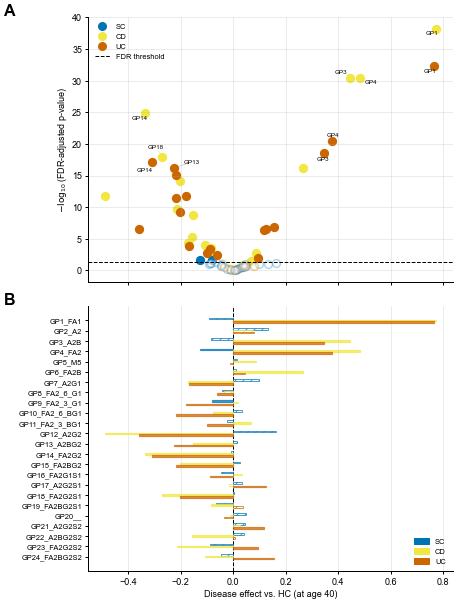

In [11]:
# Analyze disease effects (main effects only - no interactions)
df_volcano, df_bar, fdr_line, colors, ref = analyze_disease_main_effects(
    df_fixed, alpha=ALPHA, reference_group='HC', correction_method='fdr_bh', disease_colors=DISEASE_COLORS
)

# Generate plots
fig, axes = create_figure_with_panels(figsize=(6.5, 8.5), layout=(2, 1), sharex=True)

plot_disease_volcano(df_volcano, fdr_line, DISEASE_COLORS, ax=axes[0], legend_order=['SC', 'CD', 'UC'])
plot_disease_barplot(df_bar, DISEASE_COLORS, ref, ax=axes[1], legend_order=['SC', 'CD', 'UC'], group_spacing=1.5)

plt.tight_layout()
_, _ = save_figure_aga_compliant(fig=fig, filename='figure 1', format='tiff', dpi=500, path=FIGURE_DIR)

DISEASE INTERACTIONS ANALYSIS

Reference group: HC
Disease groups: CD, SC, UC
FDR threshold: 0.0500

Colors assigned:
  SC: (0.0, 0.45, 0.7)
  CD: (0.95, 0.9, 0.25)
  UC: (0.8, 0.4, 0.0)

Age Interactions:
  CD: 11/24 significant glycans
    Top positive effects:
      GP12_A2G2: β=0.0204, p=7.03e-06
      GP7_A2G1: β=0.0066, p=1.87e-02
      GP15_FA2BG2: β=0.0062, p=1.39e-04
  SC: 0/24 significant glycans
  UC: 3/24 significant glycans
    Top positive effects:
      GP4_FA2: β=-0.0066, p=3.92e-02
      GP3_A2B: β=-0.0068, p=2.60e-02
      GP1_FA1: β=-0.0120, p=2.60e-02
✓ CMYK TIFF created


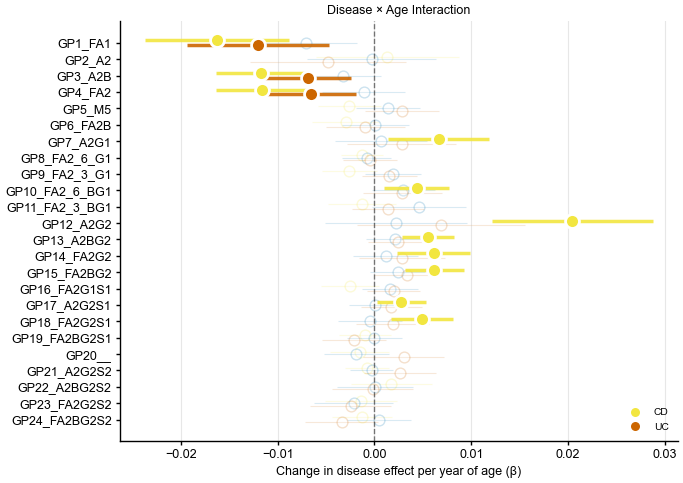

In [12]:
# Interactions
df_int = analyze_disease_interactions(
    results_fixed, df_fixed, alpha=ALPHA, reference_group='HC',
    correction_method='fdr_bh',
    disease_colors=DISEASE_COLORS
)

# Single-axis figure (Age only)
fig, ax = plt.subplots(figsize=(7, 5))
plot_interaction_lollipop(
    df_int, 'Age', DISEASE_COLORS, ax=ax, legend_order=['SC', 'CD', 'UC']
)

plt.tight_layout()
_, _ = save_figure_aga_compliant(
    fig=fig, filename='figure S3', format='tiff', dpi=500, path=FIGURE_DIR
)